In [1]:
import sys
# This is to ensure that the spack-installed packages are available in the environment
# sys.path.append('/mnt/system/spack_nfs/spack_24Q2/spack_main/var/spack/environments/python-3p9-torch2-cuda12-24Q2/.spack-env/view/lib/python3.11/site-packages')

In [59]:
import os
import numpy as np
import matplotlib.pyplot as plt 
from matplotlib import cm
import MDAnalysis as mda
from MDAnalysis.analysis.dihedrals import Ramachandran

In [60]:
run_folder = 'ala2/ala2_100ns'
# run_folder = 'ala2/ala2_10ns'

traj_file = os.path.join(run_folder, 'md.xtc')
tpr_file = os.path.join(run_folder, 'md.tpr')


In [61]:
u = mda.Universe(tpr_file, traj_file)
print(len(u.trajectory))


50001


In [70]:
ala = u.select_atoms('resname ALA')
Rama = Ramachandran(ala).run(step=1)
phi = Rama.angles[:, 0, 0] / 180 * np.pi
psi = Rama.angles[:, 0, 1] / 180 * np.pi

/mnt/projects/sne/Gohar/software_deck/pyenv-ml/lib/python3.12/site-packages/MDAnalysis/analysis/dihedrals.py:527: DeprecationWarning: The `angle` attribute was deprecated in MDAnalysis 2.0.0 and will be removed in MDAnalysis 3.0.0. Please use `results.angles` instead
  warnings.warn(wmsg, DeprecationWarning)


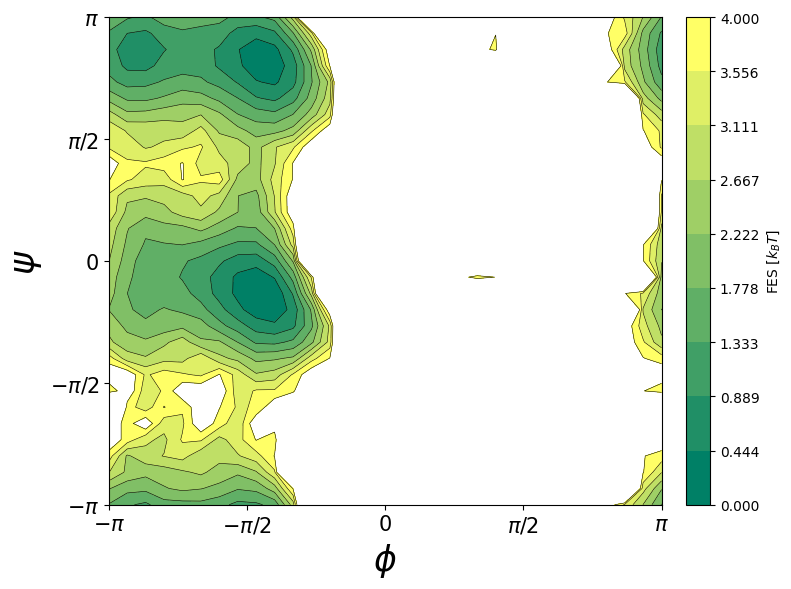

In [99]:
def free_energy_weights(a, b, T, y0, ymax, x0, xmax, w = None):
    free_energy, xedges, yedges = np.histogram2d(
        a, b, 30, [[y0, ymax], [x0, xmax]], density=True, weights=w)
    free_energy = np.log(free_energy + .000001)
    free_energy = -(0.001987*T) * free_energy
    return free_energy, xedges, yedges

dG, xedges, yedges = free_energy_weights(psi, phi, 300, -3.14, 3.14, -3.14, 3.14)

if False:
    dG -= np.amax(dG)
elif True:
    dG -= np.amin(dG)

lmax = 4#np.amax(dG)
lmin = np.amin(dG)
nlevels = 10
levels = np.linspace(lmin, lmax, nlevels)#np.arange(lmin, lmax, (lmax-lmin)/nlevels)
norm = cm.colors.Normalize(vmax=lmax, vmin=lmin)
# norm = cm.colors.Normalize(vmax=np.amax(fes), vmin=-lmax)
# cmap = cm.viridis
cmap = cm.summer
fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(8, 6))

x = xedges
y = yedges
dG = np.concatenate((dG, dG[:, 0:1]), axis=1) # periodic boundary
dG = np.concatenate((dG, dG[0:1, :]), axis=0) # periodic boundary

cset1 = ax.contourf(x, y, dG, levels, norm=norm,
                        cmap=cmap.resampled(len(levels) - 1))


cset2 = ax.contour(x, y, dG, cset1.levels, colors='k',linewidths=0.4) # For contour lines

cb = fig.colorbar(cset1, ax=ax, label=r'FES $[k_{B}T]$', fraction=0.046, pad=0.04)

plt.ylabel(r"$\psi$", size=25)
plt.xlabel(r"$\phi$", size=25)
plt.xticks([-3.14, -1.57, 0, 1.57, 3.14], [r'$-\pi$', r'$-\pi/2$', r'$0$', r'$\pi/2$', r'$\pi$'], fontsize=15)
plt.yticks([-3.14, -1.57, 0, 1.57, 3.14], [r'$-\pi$', r'$-\pi/2$', r'$0$', r'$\pi/2$', r'$\pi$'], fontsize=15)
plt.tight_layout()
plt.show()




